# Gradient descent using SymPy

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import sympy as smp

### Prepare some demonstrating data

(1.0, 0.0)
(1.5, 0.0)
(2.1, 0.0)
(2.4, 0.0)
(2.5, 1.0)
(3.1, 0.0)
(4.2, 0.0)
(4.4, 1.0)
(4.6, 1.0)
(4.9, 0.0)
(5.2, 1.0)
(5.6, 0.0)
(6.1, 1.0)
(6.4, 1.0)
(6.6, 1.0)
(7.0, 0.0)
(7.6, 1.0)
(7.8, 1.0)
(8.4, 1.0)
(8.8, 1.0)
(9.2, 1.0)


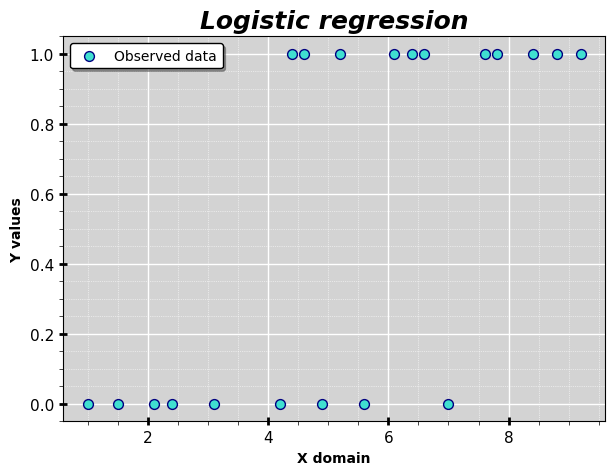

In [3]:
df = pd.read_csv("../data/logreg.csv")

x_observed = df["x"]
y_observed = df["y"]

# Plotting
plt.figure(figsize=(7,5))
ax = plt.gca()
ax.scatter(x_observed, y_observed, edgecolors="navy", color="turquoise", label="Observed data", s=50)
ax.minorticks_on()
ax.tick_params(axis="y", which='minor', width=0.5, length=3)
ax.tick_params(axis="y", which='major', width=2, length=6, direction="inout", labelsize=11)
ax.tick_params(axis="x", which='minor', width=0.5, length=3)
ax.tick_params(axis="x", which='major', width=2, length=6, direction="inout", labelsize=11)
ax.set_xlabel("X domain", fontdict={"fontweight":"bold"})
ax.set_ylabel("Y values", fontdict={"fontweight":"bold"})
ax.set_title("Logistic regression", fontsize=18, fontweight="bold", fontstyle="italic")
ax.set_facecolor("lightgrey")
ax.grid(axis="both", which='major', linewidth=1, linestyle='-', color="white")
ax.grid(axis="both", which='minor', linewidth=0.5, linestyle=':', color="white")
ax.set_axisbelow(True)
ax.legend(fancybox=True, shadow=True, facecolor="white", edgecolor="black", loc='upper left')

# Printout the coordinates (x,y)
points = [(float(x), float(y)) for x, y in zip(x_observed,y_observed)]
for point in points:
    print(point)

### ***Logistic regression and Maximum Likelihood Estimation***

Logistic regression models the probability of $Y$ being 1 (positive class) given the features $X$. This probability is given by:

$P(Y = 1 \mid X) = \frac{1}{1+e^{-(\beta_0+ \beta_1x_1+\beta_2x_2 + \dots + \beta_n x_n)}}$

where $\beta_n$​ are parameters to be learned.



In our case for a single observation $(x_i, y_i)$ the probability of observing $y_i$ given $x_i$ is:

$P(Y = y_i \mid X = x_i) = (\frac{1}{1+e^{-(\beta_0+\beta_1x_1)}})^{y_i} (1 - \frac{1}{1+e^{-(\beta_0+\beta_1x_1)}})^{1 - y_i}$

so,

$P(Y=1 \mid X = x_i) = (\frac{1}{1+e^{-(\beta_0+\beta_1x_1)}})$

$P(Y=0 \mid X = x_i) = 1 - (\frac{1}{1+e^{-(\beta_0+\beta_1x_1)}})$

It is a math trick that can handle the cases when $y_i$ equals 0.

To find the maximum likelihood estimates, we need to consider the likelihood of observing all $n$ data points. The joint likelihood function for all observations is:

$L (\beta_0, \beta_1) = \prod_{i=1}^{n} (\frac{1}{1+e^{-(\beta_0+\beta_1x_i)}})^{y_i} (1 - \frac{1}{1+e^{-(\beta_0+\beta_1x_i)}})^{1 - y_i}$

Due to floating-point underflow, it is better to avoid using a product and instead convert it into a logarithm and sum.

$\log L (\beta_0, \beta_1) = \sum_{i=1}^{n} \log ((\frac{1}{1+e^{-(\beta_0+\beta_1x_i)}})^{y_i} (1 - \frac{1}{1+e^{-(\beta_0+\beta_1x_i)}})^{1 - y_i} )$

### Calculating maximum likelihood

In [4]:
beta0, beta1, i, n = smp.symbols("beta_0, beta_1, i, n")
x, y = smp.symbols("x, y", cls=smp.Function)

# logit
logit = beta0 + beta1 * x(i)
logistic_function = 1 / (1 + smp.exp(-logit))
log_logistic_function = smp.log(logistic_function ** y(i) * (1 - logistic_function) ** (1 - y(i)))
log_likelihood = smp.Sum(log_logistic_function, (i, 0, n))
log_likelihood

Sum(log((1 - 1/(exp(-beta_0 - beta_1*x(i)) + 1))**(1 - y(i))*(1/(exp(-beta_0 - beta_1*x(i)) + 1))**y(i)), (i, 0, n))

In [5]:
log_likelihood = log_likelihood.subs(n, len(points) - 1).doit() \
.replace(x, lambda i: points[i][0]) \
.replace(y, lambda i: points[i][1])
log_likelihood = log_likelihood.simplify()

### Partial derivative of the likelihood function in respect to $\beta_0$

In [6]:
log_likelihood_dbeta0 = smp.diff(log_likelihood, beta0)

### Partial derivative of the likelihood function in respect to $\beta_1$

In [7]:
log_likelihood_dbeta1 = smp.diff(log_likelihood, beta1)

### We compile the functions using lambdify

In [8]:
log_likelihood = smp.lambdify([beta0, beta1], log_likelihood)
log_likelihood_dbeta0 = smp.lambdify([beta0, beta1], log_likelihood_dbeta0)
log_likelihood_dbeta1 = smp.lambdify([beta0, beta1], log_likelihood_dbeta1)

### Training the model

In [9]:
# Colecting data
gradient_descent = []

beta0 = 1
beta1 = 1
L = 0.01
iterations = 4000

for i in range(iterations):

    beta0 += log_likelihood_dbeta0(beta0, beta1) * L
    beta1 += log_likelihood_dbeta1(beta0, beta1) * L
    current_loglikelihood = log_likelihood(beta0, beta1)

    # Evaluate 
    if i % 500 == 0:
        print(f"Iteration {i}: Beta0 = {beta0}, Beta1 = {beta1}, Log-Likelihood = {current_loglikelihood}")
    
    gradient_descent.append((i, beta0, beta1, current_loglikelihood))

Iteration 0: Beta0 = 0.9133864213709909, Beta1 = 0.6888907520775549, Log-Likelihood = -30.840121230389123
Iteration 500: Beta0 = -2.8889329941567494, Beta1 = 0.6415127934622226, Log-Likelihood = -9.96385716687426
Iteration 1000: Beta0 = -3.1412726359131278, Beta1 = 0.6865074025264162, Log-Likelihood = -9.946409139651065
Iteration 1500: Beta0 = -3.171422112225145, Beta1 = 0.6918953915832557, Log-Likelihood = -9.946165559815018
Iteration 2000: Beta0 = -3.175205047857096, Beta1 = 0.6925716137234628, Log-Likelihood = -9.946161735082672
Iteration 2500: Beta0 = -3.1756825201419723, Beta1 = 0.6926569675126907, Log-Likelihood = -9.9461616741715
Iteration 3000: Beta0 = -3.1757428302767443, Beta1 = 0.6926677487034275, Log-Likelihood = -9.94616167319973
Iteration 3500: Beta0 = -3.17575044884205, Beta1 = 0.692669110617952, Log-Likelihood = -9.946161673184225


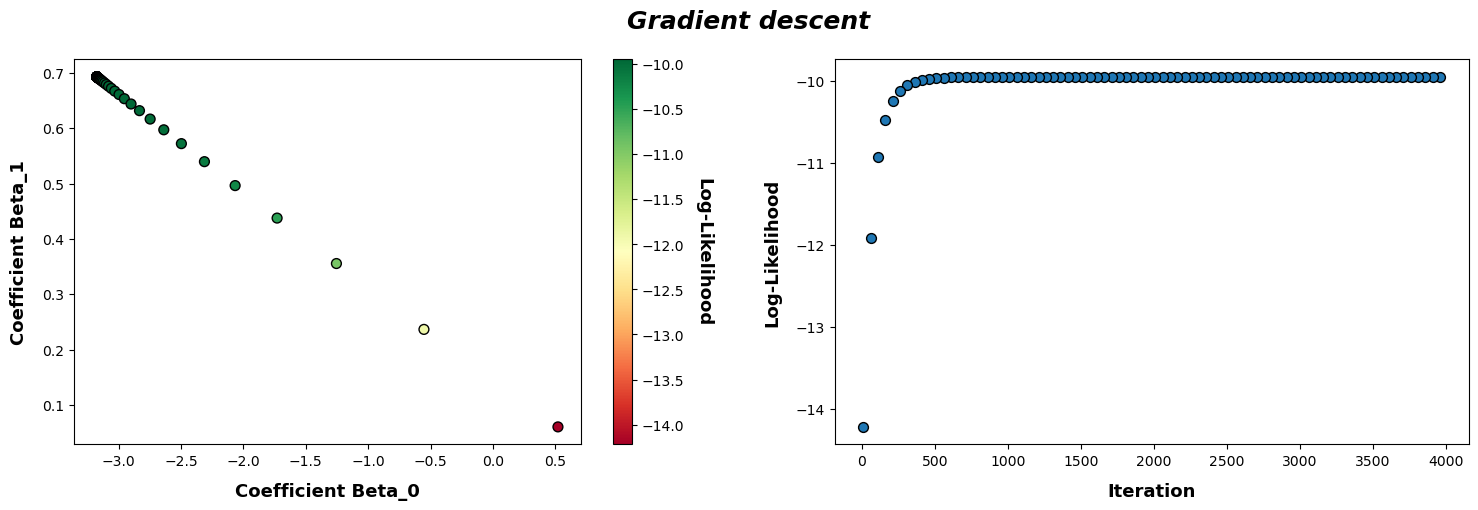

In [10]:
fig, axes = plt.subplots(figsize=(18,5), ncols=2)

# Starting from 10 every 100 element from the list
points = gradient_descent[10::50]
points.reverse()

iterations_values = [point[0] for point in points]
a_values = [point[1] for point in points]
b_values = [point[2] for point in points]
ss_values = [point[3] for point in points]

ax = axes[0]
scatter = ax.scatter(a_values, b_values, c=ss_values, cmap='RdYlGn', marker='o', edgecolors="black", s=50)
cbar = plt.colorbar(scatter, label="Cost function", ax=ax)
ax.set_xlabel("Coefficient Beta_0", fontsize=13, fontweight="bold", labelpad=10)
ax.set_ylabel("Coefficient Beta_1", fontsize=13, fontweight="bold", labelpad=10)
cbar.set_label('Log-Likelihood', rotation=-90, labelpad=20, fontsize=13, fontweight='bold')

ax = axes[1]
scatter = ax.scatter(iterations_values, ss_values, edgecolors="black", s=50)
ax.set_xlabel("Iteration", fontsize=13, fontweight="bold", labelpad=10)
ax.set_ylabel('Log-Likelihood', fontsize=13, fontweight="bold", labelpad=10)

fig.suptitle("Gradient descent", fontsize=18, fontweight="bold", fontstyle="italic", ha="center")

plt.show()

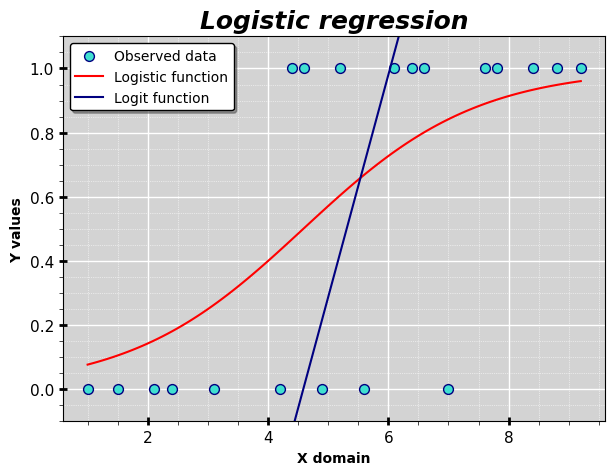

In [11]:
def logistic_function(x):
    return 1 / (1 + np.exp(-(beta0 + beta1 * x)))

def logit(x):
    return beta0 + beta1 * x

xdomain = np.linspace(x_observed.min(), x_observed.max(), 100)

plt.figure(figsize=(7,5))
ax = plt.gca()
ax.scatter(x_observed, y_observed, edgecolors="navy", color="turquoise", label="Observed data", s=50)
ax.plot(xdomain, logistic_function(xdomain), color="red", label="Logistic function")
ax.plot(xdomain, logit(xdomain), color="navy", label="Logit function")
ax.minorticks_on()
ax.set_ylim(-0.1, 1.1)
ax.tick_params(axis="y", which='minor', width=0.5, length=3)
ax.tick_params(axis="y", which='major', width=2, length=6, direction="inout", labelsize=11)
ax.tick_params(axis="x", which='minor', width=0.5, length=3)
ax.tick_params(axis="x", which='major', width=2, length=6, direction="inout", labelsize=11)
ax.set_xlabel("X domain", fontdict={"fontweight":"bold"})
ax.set_ylabel("Y values", fontdict={"fontweight":"bold"})
ax.set_title("Logistic regression", fontsize=18, fontweight="bold", fontstyle="italic")
ax.set_facecolor("lightgrey")
ax.grid(axis="both", which='major', linewidth=1, linestyle='-', color="white")
ax.grid(axis="both", which='minor', linewidth=0.5, linestyle=':', color="white")
ax.set_axisbelow(True)
ax.legend(fancybox=True, shadow=True, facecolor="white", edgecolor="black", loc='upper left')
plt.show()